# PHQ-8 Depression Detection - Mental-RoBERTa + LSTM + Attention Pooling + MLP (Classification)

This notebook keeps the original frozen Mental-RoBERTa chunk-feature pipeline and adds an LSTM over the chunk sequence before attention pooling for participant-level classification.


## 1. Install Dependencies

In [1]:
!pip install transformers tqdm pandas numpy scikit-learn matplotlib nltk --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [2]:
import os
import random

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

print("Imports successful.")

Imports successful.


In [3]:
# --- Reproducibility ---
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Global seed    : {SEED}")

# --- Paths ---
BASE_DIR        = Path("..")
DATASET_DIR     = BASE_DIR / "dataset"
TRANSCRIPT_DIR  = DATASET_DIR / "cleaned"
PROCESSED_DIR   = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / "train_split_Depression_AVEC2017.csv"
DEV_CSV   = DATASET_DIR / "dev_split_Depression_AVEC2017.csv"
TEST_CSV  = DATASET_DIR / "full_test_split.csv"

FEATURE_CACHE = PROCESSED_DIR / "mental_roberta_features_cls.npz"
EDA_CACHE    = PROCESSED_DIR / "mental_roberta_features_eda_cls.npz"

MENTAL_ROBERTA_MODEL_ID = str(Path("models") / "mental_roberta")  # local model folder inside experiments/

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "mental_roberta_lstm_cls"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Global seed    : 42
Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\mental_roberta_features_cls.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\mental_roberta_lstm_cls


## 3. Load Label Files

Binary labels:
- `PHQ8_Binary` in train/dev CSVs â€” 1 if PHQ-8 â‰¥ 10, else 0
- `PHQ_Binary` in test CSV (same threshold, different column name)

In [4]:
train_df = pd.read_csv(TRAIN_CSV)[["Participant_ID", "PHQ8_Binary"]]
dev_df   = pd.read_csv(DEV_CSV)[["Participant_ID", "PHQ8_Binary"]]
test_df  = pd.read_csv(TEST_CSV)[["Participant_ID", "PHQ_Binary"]].rename(
    columns={"PHQ_Binary": "PHQ8_Binary"}
)

train_labels = dict(zip(train_df.Participant_ID, train_df.PHQ8_Binary))
dev_labels   = dict(zip(dev_df.Participant_ID,   dev_df.PHQ8_Binary))
test_labels  = dict(zip(test_df.Participant_ID,  test_df.PHQ8_Binary))

pid_to_label = {**train_labels, **dev_labels, **test_labels}
pid_to_split = (
    {pid: "train" for pid in train_labels}
    | {pid: "dev"   for pid in dev_labels}
    | {pid: "test"  for pid in test_labels}
)

for name, labels in [("Train", train_labels), ("Dev", dev_labels), ("Test", test_labels)]:
    dep  = sum(labels.values())
    ctrl = len(labels) - dep
    print(f"{name:5s}: {len(labels):3d} participants  "
          f"depressed: {dep}  control: {ctrl}")

Train: 107 participants  depressed: 30  control: 77
Dev  :  35 participants  depressed: 12  control: 23
Test :  47 participants  depressed: 14  control: 33


## 4. Feature Extraction

Transcripts in `dataset/transcripts/` are chunked into **200-token windows** with a **50-token overlap**.
Each chunk is passed through frozen Mental-RoBERTa and the **[CLS] token embedding** (first token `<s>`) is taken -> **768-dim feature vector**.

Features are saved to `processed/mental_roberta_features_cls.npz` and reloaded on subsequent runs.
The new LSTM operates on the cached chunk sequence, so feature extraction stays unchanged.


In [5]:
CHUNK_TOKENS   = 200   # tokens per chunk (excluding special tokens)
OVERLAP_TOKENS = 50    # overlapping tokens between consecutive chunks
STRIDE         = CHUNK_TOKENS - OVERLAP_TOKENS

if FEATURE_CACHE.exists():
    print(f"Feature cache found at {FEATURE_CACHE.name} - skipping extraction.")
else:
    print(f"Extracting RoBERTa features → {FEATURE_CACHE.name}")
    print(f"  Model      : {MENTAL_ROBERTA_MODEL_ID}")
    print(f"  Chunk size : {CHUNK_TOKENS} tokens   Overlap : {OVERLAP_TOKENS} tokens")

    from transformers import RobertaModel, RobertaTokenizerFast

    tokenizer = RobertaTokenizerFast.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta   = RobertaModel.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta.eval().to(DEVICE)
    for param in roberta.parameters():
        param.requires_grad = False
    print("RoBERTa loaded and frozen.")

    all_feats, all_bin_labels, all_pids, all_splits = [], [], [], []

    transcript_files = sorted(TRANSCRIPT_DIR.glob("*_P.txt"))
    print(f"\nProcessing {len(transcript_files)} transcript files ...")

    for txt_path in tqdm(transcript_files):
        pid = int(txt_path.stem.split("_")[0])
        if pid not in pid_to_label:
            continue

        split = pid_to_split[pid]
        label = pid_to_label[pid]

        text = txt_path.read_text(encoding="utf-8").strip()
        if not text:
            continue

        # Tokenize full transcript (no special tokens yet)
        token_ids = tokenizer.encode(text, add_special_tokens=False)

        # Sliding-window chunking over token IDs
        starts = list(range(0, max(1, len(token_ids) - CHUNK_TOKENS + 1), STRIDE))
        if not starts:
            starts = [0]

        for start in starts:
            chunk_ids = token_ids[start : start + CHUNK_TOKENS]

            # RoBERTa special tokens: <s> (cls) ... </s> (sep)
            input_ids      = [tokenizer.cls_token_id] + chunk_ids + [tokenizer.sep_token_id]
            attention_mask = [1] * len(input_ids)

            input_ids_t = torch.tensor([input_ids],      device=DEVICE)
            attn_mask_t = torch.tensor([attention_mask], device=DEVICE)

            with torch.no_grad():
                outputs = roberta(
                    input_ids=input_ids_t,
                    attention_mask=attn_mask_t,
                )
            # [CLS] embedding â€” first token of last hidden state
            feat = outputs.last_hidden_state[0, 0].cpu().numpy()  # (768,)

            all_feats.append(feat)
            all_bin_labels.append(label)
            all_pids.append(pid)
            all_splits.append(split.encode())

    np.savez_compressed(
        FEATURE_CACHE,
        feats         = np.array(all_feats,      dtype=np.float32),
        binary_labels = np.array(all_bin_labels, dtype=np.int32),
        pids          = np.array(all_pids,        dtype=np.int32),
        splits        = np.array(all_splits),
    )
    print(f"\nSaved {len(all_feats):,} chunk features at {FEATURE_CACHE}")

    del roberta, tokenizer
    torch.cuda.empty_cache()

Feature cache found at mental_roberta_features_cls.npz - skipping extraction.


## 4b. EDA Feature Extraction (Training Only)

Apply **Easy Data Augmentation (EDA)** to raw training transcripts and re-extract \
Mental-RoBERTa [CLS] chunk features from the augmented texts.

Four operations per augmentation pass (training split only — dev/test untouched):
- **Synonym Replacement (SR)**: replace `EDA_ALPHA_SR` fraction of words with WordNet synonyms
- **Random Insertion (RI)**: insert a random synonym at a random position
- **Random Swap (RS)**: randomly swap pairs of words
- **Random Deletion (RD)**: delete each word independently with probability `EDA_ALPHA_RD`

Each transcript is augmented `N_AUG` times. Each augmentation becomes a separate \
"virtual participant" in training (its own chunk sequence fed to the LSTM). \
Features are cached at `processed/mental_roberta_features_eda_cls.npz`.

In [6]:
import nltk
from nltk.corpus import wordnet

# Download required NLTK data
for _resource, _kind in [
    ("wordnet",                        "corpora"),
    ("omw-1.4",                        "corpora"),
    ("averaged_perceptron_tagger_eng", "taggers"),
]:
    try:
        nltk.data.find(f"{_kind}/{_resource}")
    except LookupError:
        nltk.download(_resource, quiet=True)

# --- EDA hyperparameters ---
N_AUG        = 1      # augmented copies per training transcript
EDA_ALPHA_SR = 0.10   # fraction of words for synonym replacement
EDA_ALPHA_RI = 0.10   # fraction of words for random insertion
EDA_ALPHA_RS = 0.10   # fraction of words for random swap
EDA_ALPHA_RD = 0.10   # per-word deletion probability

# --- EDA helper functions ---
def _get_synonyms(word):
    syns = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            s = lemma.name().replace("_", " ")
            if s.lower() != word.lower():
                syns.add(s)
    return list(syns)

def _synonym_replacement(words, n):
    new_words = words[:]
    candidates = [w for w in new_words if _get_synonyms(w)]
    random.shuffle(candidates)
    for word in candidates[:n]:
        syns = _get_synonyms(word)
        if syns:
            new_words[new_words.index(word)] = random.choice(syns)
    return new_words

def _random_insertion(words, n):
    new_words = words[:]
    for _ in range(n):
        syns, attempts = [], 0
        while not syns and attempts < 10:
            syns = _get_synonyms(random.choice(words))
            attempts += 1
        if syns:
            new_words.insert(random.randint(0, len(new_words)), random.choice(syns))
    return new_words

def _random_swap(words, n):
    new_words = words[:]
    for _ in range(n):
        if len(new_words) >= 2:
            i, j = random.sample(range(len(new_words)), 2)
            new_words[i], new_words[j] = new_words[j], new_words[i]
    return new_words

def _random_deletion(words, p):
    if len(words) == 1:
        return words[:]
    result = [w for w in words if random.random() > p]
    return result if result else [random.choice(words)]

def eda_augment(text):
    """One EDA pass: SR -> RI -> RS -> RD."""
    words = text.split()
    n = max(1, int(len(words) * EDA_ALPHA_SR))
    words = _synonym_replacement(words, n)
    n = max(1, int(len(words) * EDA_ALPHA_RI))
    words = _random_insertion(words, n)
    n = max(1, int(len(words) * EDA_ALPHA_RS))
    words = _random_swap(words, n)
    words = _random_deletion(words, EDA_ALPHA_RD)
    return " ".join(words)

# --- Extract features for EDA-augmented training transcripts ---
if EDA_CACHE.exists():
    print(f"EDA feature cache found at {EDA_CACHE.name} — skipping extraction.")
else:
    print(f"Extracting EDA-augmented features → {EDA_CACHE.name}")
    print(f"  N_AUG={N_AUG}  SR={EDA_ALPHA_SR}  RI={EDA_ALPHA_RI}  "
          f"RS={EDA_ALPHA_RS}  RD={EDA_ALPHA_RD}")

    from transformers import RobertaModel, RobertaTokenizerFast

    tokenizer = RobertaTokenizerFast.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta   = RobertaModel.from_pretrained(MENTAL_ROBERTA_MODEL_ID)
    roberta.eval().to(DEVICE)
    for param in roberta.parameters():
        param.requires_grad = False
    print("RoBERTa loaded and frozen.")

    eda_feats_list, eda_labels_list, eda_pids_list, eda_aug_list = [], [], [], []
    train_pids     = set(train_labels.keys())
    train_files    = [p for p in sorted(TRANSCRIPT_DIR.glob("*_P.txt"))
                      if int(p.stem.split("_")[0]) in train_pids]
    print(f"\nApplying EDA to {len(train_files)} training transcripts "
          f"({N_AUG} augmentation(s) each) ...")

    for txt_path in tqdm(train_files):
        pid   = int(txt_path.stem.split("_")[0])
        label = pid_to_label[pid]
        text  = txt_path.read_text(encoding="utf-8").strip()
        if not text:
            continue

        for aug_i in range(N_AUG):
            aug_text  = eda_augment(text)
            token_ids = tokenizer.encode(aug_text, add_special_tokens=False)
            starts    = list(range(0, max(1, len(token_ids) - CHUNK_TOKENS + 1), STRIDE))
            if not starts:
                starts = [0]

            for start in starts:
                chunk_ids      = token_ids[start : start + CHUNK_TOKENS]
                input_ids      = [tokenizer.cls_token_id] + chunk_ids + [tokenizer.sep_token_id]
                attention_mask = [1] * len(input_ids)

                input_ids_t = torch.tensor([input_ids],      device=DEVICE)
                attn_mask_t = torch.tensor([attention_mask], device=DEVICE)

                with torch.no_grad():
                    out  = roberta(input_ids=input_ids_t, attention_mask=attn_mask_t)
                feat = out.last_hidden_state[0, 0].cpu().numpy()

                eda_feats_list.append(feat)
                eda_labels_list.append(label)
                eda_pids_list.append(pid)
                eda_aug_list.append(aug_i)

    np.savez_compressed(
        EDA_CACHE,
        feats         = np.array(eda_feats_list,  dtype=np.float32),
        binary_labels = np.array(eda_labels_list, dtype=np.int32),
        pids          = np.array(eda_pids_list,   dtype=np.int32),
        aug_indices   = np.array(eda_aug_list,    dtype=np.int32),
    )
    n_dep_eda  = sum(eda_labels_list)
    n_ctrl_eda = len(eda_labels_list) - n_dep_eda
    print(f"\nSaved {len(eda_feats_list):,} EDA chunk features  "
          f"(depressed chunks: {n_dep_eda:,}  control chunks: {n_ctrl_eda:,})")

    del roberta, tokenizer
    torch.cuda.empty_cache()

EDA feature cache found at mental_roberta_features_eda_cls.npz — skipping extraction.


## 5. Build Participant-Level Dataset

Load the cached features and group chunks by participant in chunk order.
The LSTM models temporal context across chunk embeddings, then attention pooling learns which encoded chunks matter most.


In [7]:
print(f"Loading features from {FEATURE_CACHE.name} ...")
cache           = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np    = cache["feats"]          # (N, 768)
all_labels_np   = cache["binary_labels"]  # (N,)
all_pids_np     = cache["pids"]           # (N,)
all_splits_np   = cache["splits"]         # (N,)  byte strings

in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, lbl, pid, split_b in zip(
    all_feats_np, all_labels_np, all_pids_np, all_splits_np
):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = int(lbl)

# --- Merge EDA-augmented features into training (each augmentation = separate virtual participant) ---
if EDA_CACHE.exists():
    print(f"Loading EDA features from {EDA_CACHE.name} ...")
    eda_cache      = np.load(EDA_CACHE, allow_pickle=False)
    eda_feats_np   = eda_cache["feats"]
    eda_labels_np  = eda_cache["binary_labels"]
    eda_pids_np    = eda_cache["pids"]
    eda_augs_np    = eda_cache["aug_indices"]

    # Each (pid, aug_index) pair becomes a unique virtual participant (separate LSTM sequence)
    eda_virtual: dict = defaultdict(lambda: {"feats": [], "label": None})
    for feat, lbl, pid, aug_i in zip(
        eda_feats_np, eda_labels_np, eda_pids_np, eda_augs_np
    ):
        virtual_pid = int(pid) * 1000 + int(aug_i)  # unique key; no collision with real PIDs < 1000
        eda_virtual[virtual_pid]["feats"].append(feat)
        eda_virtual[virtual_pid]["label"] = int(lbl)

    for vpid, data in eda_virtual.items():
        in_memory["train"][vpid] = data

    n_eda_dep  = sum(d["label"] for d in eda_virtual.values())
    n_eda_ctrl = len(eda_virtual) - n_eda_dep
    print(f"  Added {len(eda_virtual)} EDA virtual participants to training "
          f"(depressed: {n_eda_dep}  control: {n_eda_ctrl})")
else:
    print("EDA cache not found — run the EDA extraction cell first.")

splits_list = {s: list(in_memory[s].items()) for s in ("train", "dev", "test")}

print(f"\n{'Split':10s}  {'Participants':>12}  {'Chunks':>8}  {'Depressed':>9}  {'Control':>7}")
print("-" * 52)
for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_chunks = sum(len(d["feats"]) for _, d in splits_list[s])
    n_dep    = sum(d["label"] for _, d in splits_list[s])
    n_ctrl   = len(splits_list[s]) - n_dep
    print(f"{name:10s}  {len(splits_list[s]):12d}  {n_chunks:8,}  {n_dep:9d}  {n_ctrl:7d}")

Loading features from mental_roberta_features_cls.npz ...
Loading EDA features from mental_roberta_features_eda_cls.npz ...
  Added 107 EDA virtual participants to training (depressed: 30  control: 77)

Split       Participants    Chunks  Depressed  Control
----------------------------------------------------
train                214     2,049         60      154
validation            35       354         12       23
test                  47       519         14       33


## 6. Training Configuration

In [8]:
# --- Model hyper-parameters ---
MENTAL_ROBERTA_DIM = 768
LSTM_HIDDEN        = 64
LSTM_LAYERS        = 1
LSTM_BIDIRECTIONAL = False
MLP_HIDDEN         = 64
DROPOUT            = 0.6

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 16
NUM_EPOCHS              = 1000
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 100
CHECKPOINT_FREQ         = 50
GRAD_CLIP_NORM          = 1.0

LSTM_OUT_DIM = LSTM_HIDDEN * (2 if LSTM_BIDIRECTIONAL else 1)

print("Training configuration:")
print(f"  RoBERTa feature dim    : {MENTAL_ROBERTA_DIM}")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN}")
print(f"  LSTM layers            : {LSTM_LAYERS}")
print(f"  LSTM bidirectional     : {LSTM_BIDIRECTIONAL}")
print(f"  LSTM output dim        : {LSTM_OUT_DIM}")
print(f"  MLP hidden dim         : {MLP_HIDDEN}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs patience")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")


Training configuration:
  RoBERTa feature dim    : 768
  LSTM hidden dim        : 64
  LSTM layers            : 1
  LSTM bidirectional     : False
  LSTM output dim        : 64
  MLP hidden dim         : 64
  Dropout                : 0.6
  Participant batch size : 16
  Epochs                 : 1000
  Learning rate          : 0.0001
  Weight decay           : 0.0001
  Early stopping         : 100 epochs patience
  Grad clip norm         : 1.0


## 7. Model - RoBERTa LSTM Attention Pooling + MLP Classifier

```
Input  : (T, 768)  [CLS] chunk embeddings for one participant
         LSTM(768, 256, bidirectional=True) -> (T, 512)
         Linear(512, 1) + softmax over T
         attention-weighted sum -> (512,)   [learned chunk importance after sequence encoding]
         LayerNorm(512)
         Linear(512, 128) + ReLU
         Dropout(0.3)
         Linear(128, 1)
Output : scalar logit  (sigmoid -> probability of depression)
```


In [9]:
class MentalRoBERTaLSTMAttentionMLPClassifier(nn.Module):
    """
    LSTM encoder + attention pooling + LayerNorm + MLP binary classifier
    on top of frozen Mental-RoBERTa [CLS] chunk features.

    Input  : (T, 768) chunk embeddings for one participant
    Output : scalar logit positive = depressed, negative = control
    """
    def __init__(
        self,
        input_dim: int = MENTAL_ROBERTA_DIM,
        lstm_hidden: int = LSTM_HIDDEN,
        lstm_layers: int = LSTM_LAYERS,
        bidirectional: bool = LSTM_BIDIRECTIONAL,
        hidden_dim: int = MLP_HIDDEN,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        self.lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )
        self.attention = nn.Linear(self.lstm_out_dim, 1)
        self.norm = nn.LayerNorm(self.lstm_out_dim)
        self.input_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(self.lstm_out_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def encode_sequence(self, x: torch.Tensor) -> torch.Tensor:
        # x : (T, 768) -> add batch axis for LSTM
        encoded, _ = self.lstm(self.input_dropout(x).unsqueeze(0))
        return encoded.squeeze(0)  # (T, lstm_out_dim)

    def get_attention_weights(self, x: torch.Tensor):
        encoded = self.encode_sequence(x)
        attn_weights = torch.softmax(self.attention(encoded), dim=0)
        return encoded, attn_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        encoded, attn_weights = self.get_attention_weights(x)
        pooled = (attn_weights * encoded).sum(dim=0)
        pooled = self.norm(pooled)
        return self.classifier(pooled).squeeze()


model = MentalRoBERTaLSTMAttentionMLPClassifier().to(DEVICE)

# Sanity-check forward pass
with torch.no_grad():
    dummy = torch.zeros(10, MENTAL_ROBERTA_DIM, device=DEVICE)
    out = model(dummy)
    print(f"Output shape (10 chunks): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")


Output shape (10 chunks): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 217,922


## 8. Training Loop

**Participant-level training**: each participant's ordered chunk sequence is fed through the LSTM, then attention pooling produces one participant vector and one logit.

**Class-weighted loss**: `pos_weight = sqrt(n_control / n_depressed)` compensates for class imbalance.

**Data augmentation** (training only, never applied during eval):
- **Random chunk subsampling**: each training pass randomly keeps `AUGMENT_CHUNK_KEEP`–100% of a participant's chunks (preserving order), preventing the LSTM from memorising specific chunk positions.
- **Gaussian feature noise**: small zero-mean noise (`AUGMENT_NOISE_STD`) is added to the 768-dim embeddings, acting as input regularisation.

**Threshold tuning**: after training, the decision threshold is tuned on the validation set to maximise macro F1.


In [10]:
# --- Augmentation hyperparameters ---
AUGMENT_NOISE_STD  = 0.03   # std of Gaussian noise added to chunk embeddings
AUGMENT_CHUNK_KEEP = 0.75   # minimum fraction of chunks to keep per training pass
# Class-weighted loss
n_dep_train  = sum(d["label"] for _, d in splits_list["train"])
n_ctrl_train = len(splits_list["train"]) - n_dep_train
pos_weight   = torch.tensor(1.0, dtype=torch.float32, device=DEVICE)
print(f"Training class counts - depressed: {n_dep_train}, control: {n_ctrl_train}")
print(f"BCEWithLogitsLoss pos_weight: {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_participants = splits_list["train"]

# Training index (no oversampling; pos_weight handles class imbalance)
train_idx = list(range(len(train_participants)))
print(f"\nTraining pool: {len(train_idx)} samples")
print(f"Augmentation: noise_std={AUGMENT_NOISE_STD}, chunk_keep_min={AUGMENT_CHUNK_KEEP:.0%}")

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": [],
}
best_val_loss     = float("inf")
epochs_no_improve = 0


def augment_feats(feats: torch.Tensor) -> torch.Tensor:
    """Random chunk subsampling + Gaussian noise. Applied only during training."""
    T = feats.size(0)
    if T > 1:
        # Keep between AUGMENT_CHUNK_KEEP and 100% of chunks, in original order
        keep_frac = AUGMENT_CHUNK_KEEP + (1.0 - AUGMENT_CHUNK_KEEP) * torch.rand(1).item()
        n_keep    = max(1, int(T * keep_frac))
        keep_idx  = torch.randperm(T)[:n_keep].sort().values
        feats     = feats[keep_idx]
    # Additive Gaussian noise
    feats = feats + torch.randn_like(feats) * AUGMENT_NOISE_STD
    return feats


def train_epoch():
    model.train()
    # Shuffle training index each epoch
    perm    = torch.randperm(len(train_idx)).tolist()
    idx     = [train_idx[p] for p in perm]
    batches = [
        idx[i : i + PARTICIPANT_BATCH_SIZE]
        for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)
    ]
    total_loss = 0.0
    correct    = 0
    n          = len(idx)

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            feats = augment_feats(feats)  # <-- augmentation (training only)
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit = model(feats)
            loss  = criterion(logit, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            pred        = 1 if torch.sigmoid(logit).item() >= 0.5 else 0
            correct    += int(pred == data["label"])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n, correct / n


def evaluate(split: str, threshold: float = 0.5):
    """
    Participant-level evaluation. No augmentation applied.
    Returns (avg_loss, accuracy, macro_f1, results_df).
    """
    model.eval()
    total_loss = 0.0
    correct    = 0
    records    = []

    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            label = torch.tensor(
                float(data["label"]), dtype=torch.float32, device=DEVICE
            )

            logit      = model(feats)
            loss       = criterion(logit, label)
            total_loss += loss.item()

            pred_prob = torch.sigmoid(logit).item()
            pred      = 1 if pred_prob >= threshold else 0
            correct  += int(pred == data["label"])
            records.append((pid, pred, pred_prob, data["label"]))

    n          = len(splits_list[split])
    results_df = pd.DataFrame(records, columns=["pid", "pred", "prob", "label"])
    f1         = f1_score(results_df["label"], results_df["pred"], average="macro", zero_division=0)
    return total_loss / n, correct / n, f1, results_df


# Main training loop with early stopping and checkpointing
best_ckpt = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch()
    val_loss,   val_acc, val_f1, _ = evaluate("dev")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    # Checkpoint every CHECKPOINT_FREQ epochs
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_mental_roberta_lstm_cls.pth"
        torch.save(model.state_dict(), ckpt_path)

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        best_ckpt = {
            "epoch":    epoch,
            "val_loss": val_loss,
            "val_acc":  val_acc,
            "val_f1":   val_f1,
            "state":    {k: v.cpu().clone() for k, v in model.state_dict().items()},
        }
        best_path = SAVE_DIR / "mental_roberta_lstm_cls_best.pth"
        torch.save(best_ckpt["state"], best_path)
    else:
        epochs_no_improve += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:4d}/{NUM_EPOCHS}  "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}"
        )

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        break

print(f"\nBest checkpoint: epoch {best_ckpt['epoch']}  "
      f"val_loss={best_ckpt['val_loss']:.4f}  val_acc={best_ckpt['val_acc']:.4f}  "
      f"val_f1={best_ckpt['val_f1']:.4f}")

# Restore best weights
model.load_state_dict(best_ckpt["state"])
model.to(DEVICE)

# Tune decision threshold on validation set
thresholds  = np.arange(0.1, 0.91, 0.05)
best_thresh = 0.5
best_f1     = -1.0

for thresh in thresholds:
    _, _, _, val_df = evaluate("dev", threshold=thresh)
    macro_f1 = f1_score(val_df["label"], val_df["pred"], average="macro", zero_division=0)
    if macro_f1 > best_f1:
        best_f1     = macro_f1
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}  (val macro-F1 = {best_f1:.4f})")

Training class counts - depressed: 60, control: 154
BCEWithLogitsLoss pos_weight: 1.0000

Training pool: 214 samples
Augmentation: noise_std=0.03, chunk_keep_min=75%
Epoch   10/1000  train_loss=0.5825  train_acc=0.7150  val_loss=0.6469  val_acc=0.6571  val_f1=0.3966
Epoch   20/1000  train_loss=0.6023  train_acc=0.7196  val_loss=0.6465  val_acc=0.6571  val_f1=0.3966
Epoch   30/1000  train_loss=0.6063  train_acc=0.7196  val_loss=0.6512  val_acc=0.6571  val_f1=0.3966
Epoch   40/1000  train_loss=0.5924  train_acc=0.7196  val_loss=0.6502  val_acc=0.6571  val_f1=0.3966
Epoch   50/1000  train_loss=0.5776  train_acc=0.7196  val_loss=0.6527  val_acc=0.6571  val_f1=0.3966
Epoch   60/1000  train_loss=0.5807  train_acc=0.7196  val_loss=0.6519  val_acc=0.6571  val_f1=0.3966
Epoch   70/1000  train_loss=0.5687  train_acc=0.7196  val_loss=0.6460  val_acc=0.6571  val_f1=0.3966
Epoch   80/1000  train_loss=0.5832  train_acc=0.7243  val_loss=0.6451  val_acc=0.6571  val_f1=0.3966
Epoch   90/1000  train_los

## 9. Training Curves

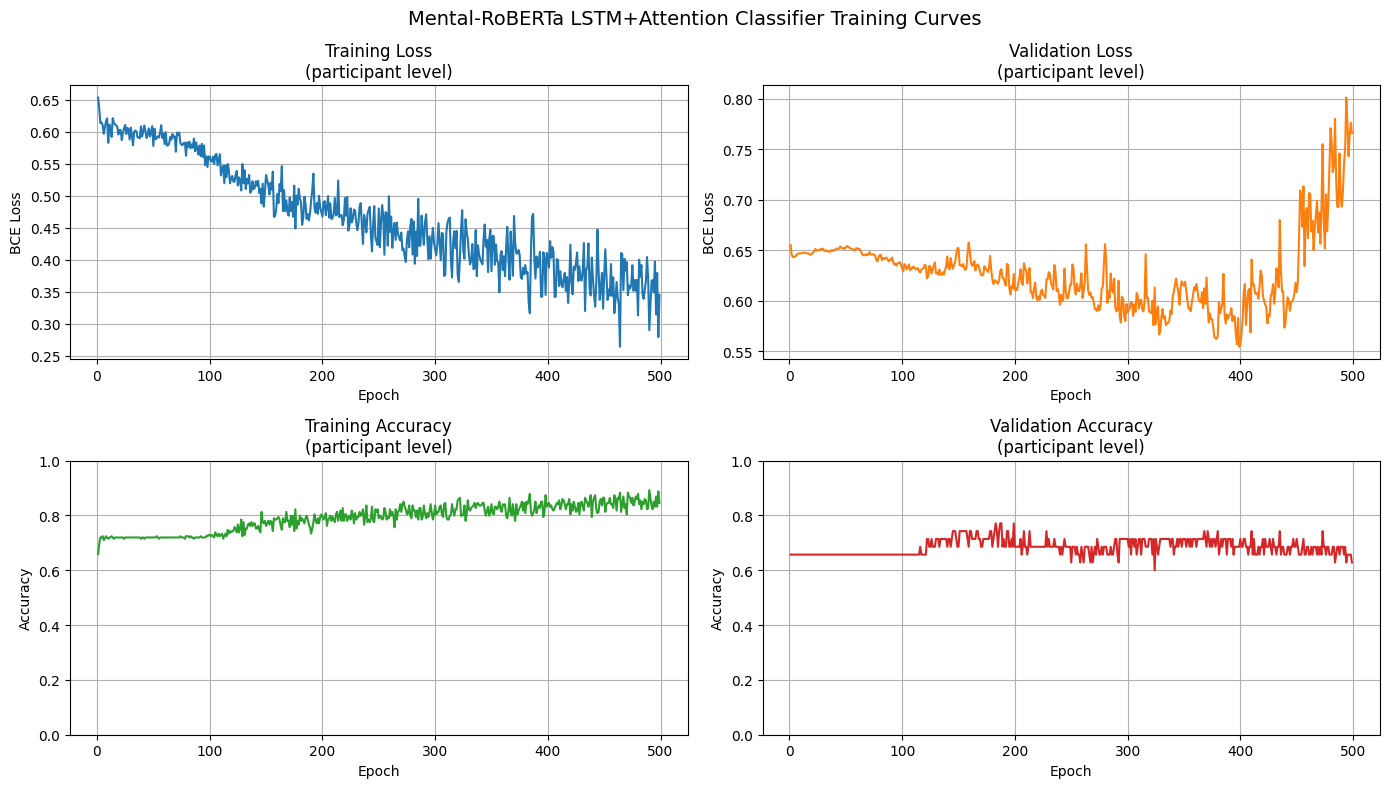

In [11]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE Loss")
axes[0, 0].set_title("Training Loss\n(participant level)")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("BCE Loss")
axes[0, 1].set_title("Validation Loss\n(participant level)")
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_ran, history["train_acc"], color="tab:green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Training Accuracy\n(participant level)")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_ran, history["val_acc"], color="tab:red")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Validation Accuracy\n(participant level)")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True)

plt.suptitle("Mental-RoBERTa LSTM+Attention Classifier Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Attention Weight Visualisation

Inspect which transcript chunks the model attends to for a sample of test participants.
High attention weights indicate the model found those chunks most informative for its prediction.

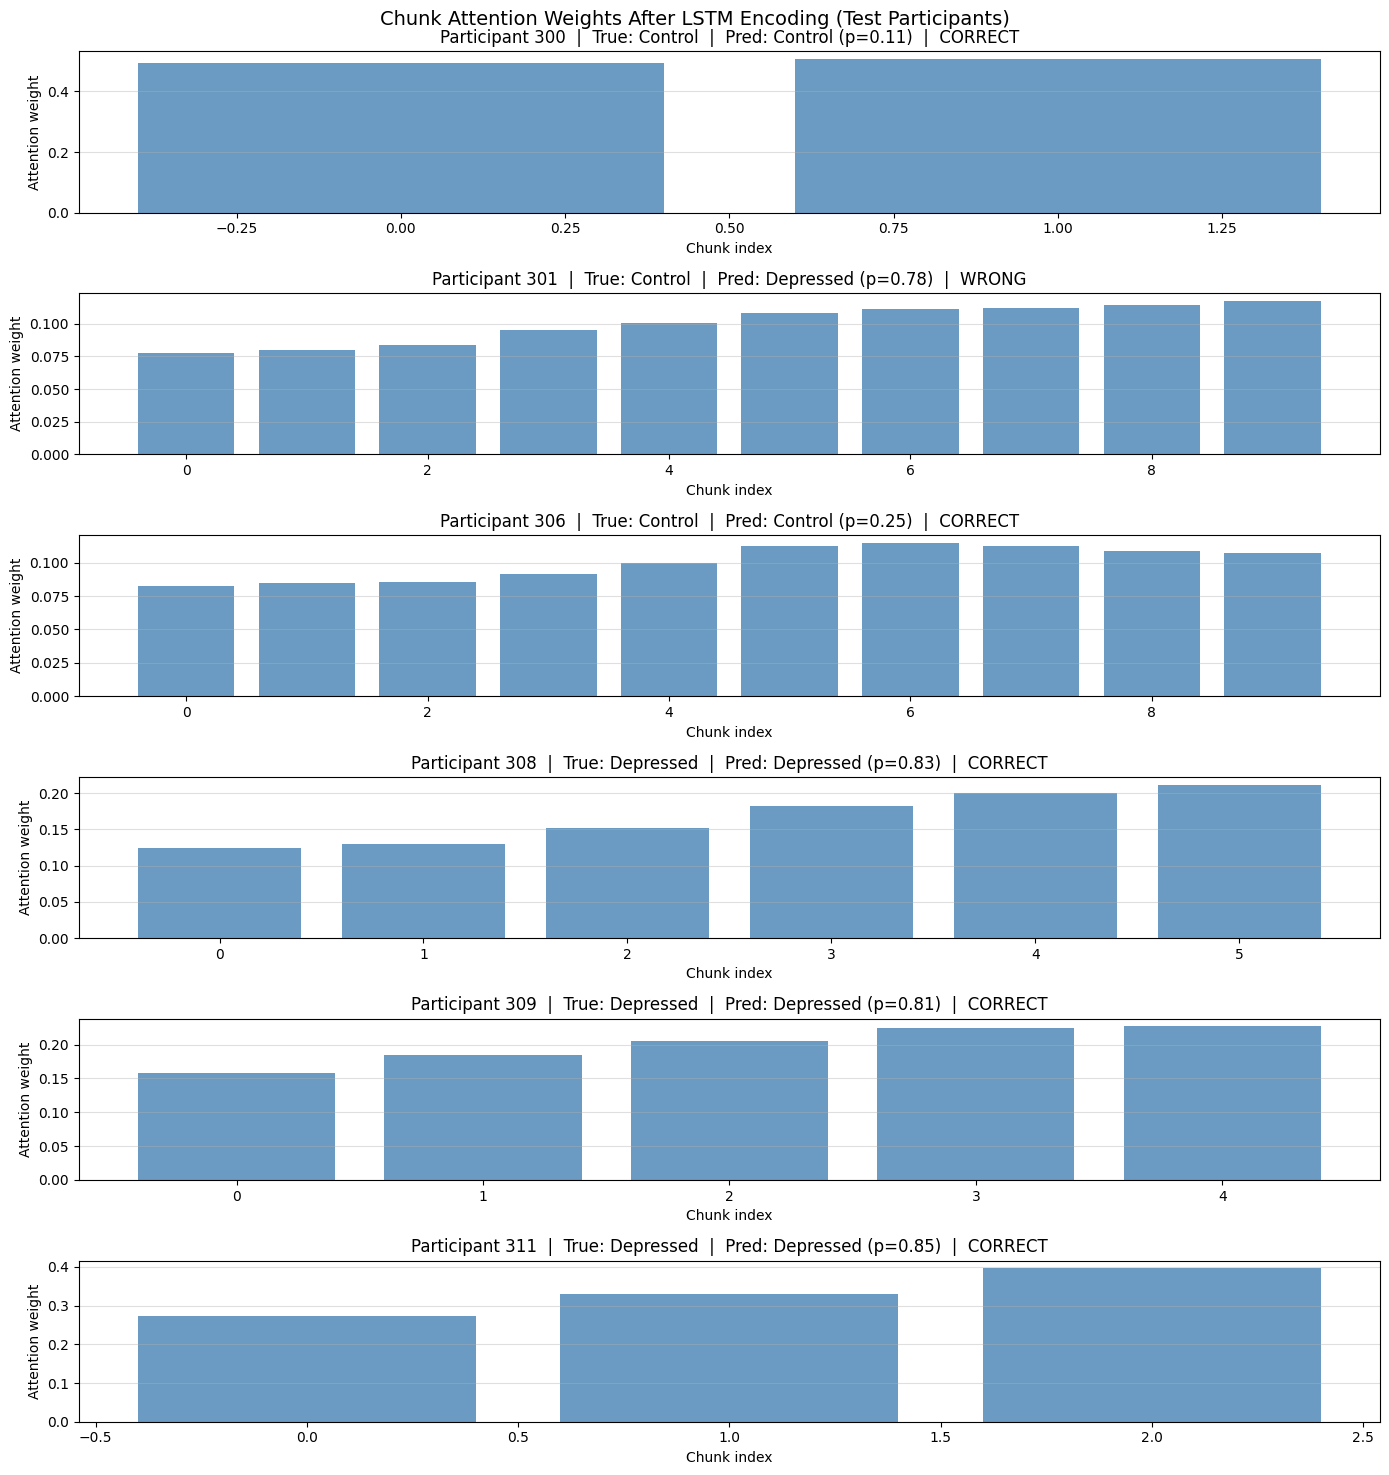

In [12]:
model.eval()
n_show = min(6, len(splits_list["test"]))
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show))
if n_show == 1:
    axes = [axes]

with torch.no_grad():
    for ax, (pid, data) in zip(axes, splits_list["test"][:n_show]):
        feats = torch.tensor(
            np.array(data["feats"]), dtype=torch.float32, device=DEVICE
        )
        _, attn_weights = model.get_attention_weights(feats)
        attn_weights = attn_weights.squeeze().cpu().numpy()

        logit = model(feats)
        pred_prob = torch.sigmoid(logit).item()
        pred = 1 if pred_prob >= best_thresh else 0
        true_lbl = data["label"]

        chunk_axis = np.arange(len(attn_weights))
        ax.bar(chunk_axis, attn_weights, color="steelblue", alpha=0.8)
        ax.set_xlabel("Chunk index")
        ax.set_ylabel("Attention weight")
        status = "CORRECT" if pred == true_lbl else "WRONG"
        label_str = "Depressed" if true_lbl == 1 else "Control"
        pred_str = "Depressed" if pred == 1 else "Control"
        ax.set_title(
            f"Participant {pid}  |  True: {label_str}  |  "
            f"Pred: {pred_str} (p={pred_prob:.2f})  |  {status}"
        )
        ax.grid(True, axis="y", alpha=0.4)

plt.suptitle("Chunk Attention Weights After LSTM Encoding (Test Participants)", fontsize=14)
plt.tight_layout()
plt.show()


## 11. Evaluation on Test Set

Loads the best checkpoint (lowest validation loss) and reports participant-level
**accuracy, precision, recall, and F1 score** using the validation-tuned threshold.

In [13]:
# best_ckpt and model already loaded + threshold tuned at end of training cell
_, _, _, test_results_df = evaluate("test", threshold=best_thresh)

y_true = test_results_df["label"].values.astype(int)
y_pred = test_results_df["pred"].values.astype(int)

test_acc  = accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec  = recall_score(y_true, y_pred, zero_division=0)
test_f1   = f1_score(y_true, y_pred, zero_division=0)

print(f"Best checkpoint : epoch {best_ckpt['epoch']}  "
      f"(val loss {best_ckpt['val_loss']:.4f}, val acc {best_ckpt['val_acc']:.4f}, "
      f"val_f1 {best_ckpt['val_f1']:.4f})")
print(f"Decision threshold: {best_thresh:.2f}  (tuned on validation macro-F1)")
print(f"\nParticipants evaluated: {len(test_results_df)}")
print()
print("Test-set results (participant level)")
print(f"  Accuracy  : {test_acc:.4f}  "
      f"({int(test_acc * len(y_true))}/{len(y_true)} correct)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1 Score  : {test_f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Control", "Depressed"], zero_division=0))

Best checkpoint : epoch 399  (val loss 0.5544, val acc 0.6857, val_f1 0.6578)
Decision threshold: 0.60  (tuned on validation macro-F1)

Participants evaluated: 47

Test-set results (participant level)
  Accuracy  : 0.8085  (38/47 correct)
  Precision : 0.6316
  Recall    : 0.8571
  F1 Score  : 0.7273

              precision    recall  f1-score   support

     Control       0.93      0.79      0.85        33
   Depressed       0.63      0.86      0.73        14

    accuracy                           0.81        47
   macro avg       0.78      0.82      0.79        47
weighted avg       0.84      0.81      0.82        47



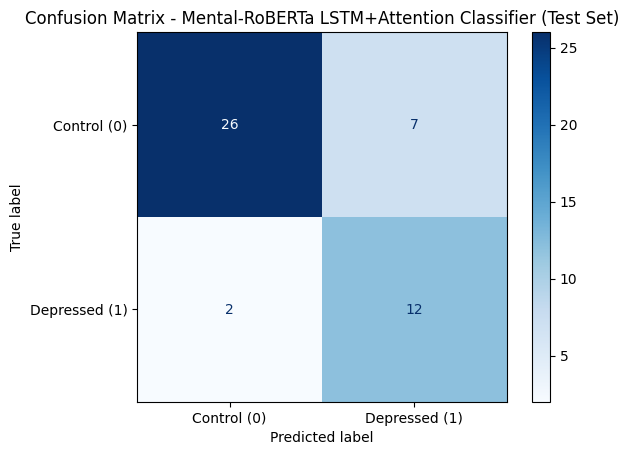

In [14]:
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control (0)", "Depressed (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Mental-RoBERTa LSTM+Attention Classifier (Test Set)")
plt.show()